# Notebook 01 — Baseline de colorización (OpenCV-DNN, CIE-Lab)

En este cuaderno construimos la **primera versión funcional** de la implementación:

- Partimos de imágenes **originales a color** en `../imgs/I*.jpg`.
- Para cada imagen generamos una versión **en escala de grises** (`I*_gray.jpg`), que simula la entrada real al sistema.
- Aplicamos el modelo de Zhang et al. (vía `cv.dnn`) sobre esa imagen en gris (canal L) para obtener una versión **colorizada** (`I*_color.png`).
- Trabajamos en el espacio **CIE-Lab**: la red recibe L (luminancia) y predice a,b (crominancia); después reconstruimos la imagen en color.

Las salidas (`I*_color.png`) y las imágenes originales (`I*.jpg`) se usarán después en el Notebook 02 para calcular PSNR y SSIM.

In [ ]:
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

BASE = Path('..').resolve()
MODELS = BASE / 'Proyecto'/'models'

DATA_RAW = (BASE /'Proyecto'/ 'imgs')
DATA_RES = (BASE /'Proyecto'/'imgs_out')

PROTOTXT   = MODELS / 'colorization_deploy_v2.prototxt'
CAFFEMODEL = MODELS / 'colorization_release_v2.caffemodel'
PTS_NPY    = MODELS / 'pts_in_hull.npy'

print('BASE       =', BASE)
print('RAW (in)   =', DATA_RAW)
print('RES (out)  =', DATA_RES)
print('PROTOTXT   =', PROTOTXT.name)
print('CAFFEMODEL =', CAFFEMODEL.name)
print('PTS_NPY    =', PTS_NPY.name)

BASE       = C:\Users\ander\Desktop\PID
RAW (in)   = C:\Users\ander\Desktop\PID\Proyecto\imgs
RES (out)  = C:\Users\ander\Desktop\PID\Proyecto\imgs_out
PROTOTXT   = colorization_deploy_v2.prototxt
CAFFEMODEL = colorization_release_v2.caffemodel
PTS_NPY    = pts_in_hull.npy


## Función `colorize_bgr`

Esta función implementa el pipeline completo del baseline:

1. Carga la red Caffe de Zhang et al. (`colorization_deploy_v2.prototxt` + `colorization_release_v2.caffemodel`).
2. Inyecta los 313 centros de color (`pts_in_hull.npy`) en la capa `class8_ab` y el vector de re-peso en `conv8_313_rh`.
3. **Preprocesado**:
   - convierte la imagen BGR a RGB y después a Lab normalizado en \[0,1],
   - extrae el canal **L**, lo reescala a 224×224 y centra **L − 50**,
   - construye el *blob* de entrada para `cv.dnn`.
4. **Inferencia** de la red y *upsampling* de los mapas **a,b** a la resolución original.
5. **Reconstrucción**: combina el **L** original con los **a,b** predichos, convierte de Lab a RGB/BGR y devuelve una imagen `uint8`.

Esta misma lógica se ha llevado al script `scripts/colorize_dnn.py` para poder usar el baseline desde línea de comandos.

In [16]:
def colorize_bgr(img_bgr):
    # Cargar red
    net = cv.dnn.readNetFromCaffe(str(PROTOTXT), str(CAFFEMODEL))

    # Inyección de centros ab (313x2) + re-peso
    pts = np.load(str(PTS_NPY)).transpose().reshape(2, 313, 1, 1).astype('float32')
    net.getLayer(net.getLayerId('class8_ab')).blobs    = [pts]
    net.getLayer(net.getLayerId('conv8_313_rh')).blobs = [np.full((1,313), 2.606, 'float32')]

    # Preproceso
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB).astype('float32') / 255.0
    img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2Lab)
    L = img_lab[:, :, 0]

    L_rs = cv.resize(L, (224, 224))
    L_rs -= 50
    blob = cv.dnn.blobFromImage(L_rs)

    # Forward
    net.setInput(blob)
    ab = net.forward()[0].transpose(1, 2, 0)           # H'×W'×2
    ab_up = cv.resize(ab, (img_bgr.shape[1], img_bgr.shape[0]))

    # Reconstrucción
    Lab_out = np.concatenate([L[:, :, None], ab_up], axis=2).astype('float32')
    out_rgb = cv.cvtColor(Lab_out, cv.COLOR_Lab2RGB)
    out_rgb = (np.clip(out_rgb, 0, 1) * 255.0).astype('uint8')
    out_bgr = cv.cvtColor(out_rgb, cv.COLOR_RGB2BGR)
    return out_bgr

### Demostración visual del coloreado (imagen ya en gris)

En esta celda comprobamos el comportamiento del baseline con una imagen de prueba
`ansel_adams.jpg` que **ya está en escala de grises** en `../imgs/`.

Esta imagen NO forma parte del conjunto sobre el que calcularemos métricas; se usa
solo para:

1. Cargar una imagen en gris.
2. Pasarla a BGR para alimentar la red.
3. Visualizar el resultado colorizado.

Más abajo aplicaremos el flujo completo (color → gris → colorizada) sobre nuestras
imágenes de trabajo `imagen01/02/03.jpg`, que sí se usarán para las métricas.

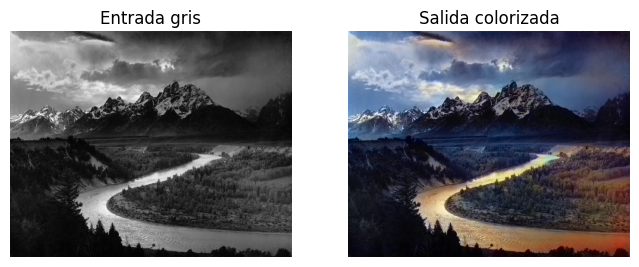

Guardado color -> C:\Users\ander\Desktop\PID\Proyecto\imgs_out\ansel_adams_color.jpg


In [19]:
# Demostración con una imagen de ejemplo ya en gris (ansel_adams.jpg)

gray_path = DATA_RAW / 'ansel_adams.jpg'   # esta imagen está en gris en ../imgs/
img_gray = cv.imread(str(gray_path), cv.IMREAD_GRAYSCALE)
assert img_gray is not None, f'No se encontró la imagen: {gray_path}'

# Convertimos la gris a BGR para alimentar la red
img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)

# Inferencia
out_bgr = colorize_bgr(img_gray_bgr)

# Guardar salida colorizada (solo demostración, no se usará en métricas)
out_path = DATA_RES / 'ansel_adams_color.jpg'
cv.imwrite(str(out_path), out_bgr)

# Mostrar entrada (gris) y salida (colorizada)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Entrada gris'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(out_bgr, cv.COLOR_BGR2RGB)); ax[1].set_title('Salida colorizada'); ax[1].axis('off')
plt.show()

print('Guardado color ->', out_path)

## Procesado por lotes de todas las imágenes `I*.jpg`

A continuación aplicamos el mismo flujo (color → gris → colorizada) a **todas las imágenes**
del directorio `../imgs/` cuyo nombre empiece por `I`:

- Entrada: `I1.jpg`, `I2.jpg`, … (originales a color).
- Guardamos `I1_gray.jpg`, `I2_gray.jpg`, … (entradas en gris).
- Guardamos `I1_color.jpg`, `I2_color.jpg`, … en `../imgs_out/`.

Estas salidas son las que luego se utilizarán en el Notebook 02 para calcular PSNR y SSIM.

In [20]:
# Colorización por lotes de todas las imágenes I*.jpg

img_paths = sorted(DATA_RAW.glob('I*.jpg'))
print(f'Se han encontrado {len(img_paths)} originales a color en {DATA_RAW}')

for img_path_color in img_paths:
    # Original a color
    img_color_bgr = cv.imread(str(img_path_color))
    if img_color_bgr is None:
        print(f'[AVISO] No se pudo leer {img_path_color}')
        continue

    # Gris
    img_gray = cv.cvtColor(img_color_bgr, cv.COLOR_BGR2GRAY)
    gray_path = DATA_RAW / f'{img_path_color.stem}_gray.jpg'
    cv.imwrite(str(gray_path), img_gray)

    # Colorización desde gris
    img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)
    out_bgr = colorize_bgr(img_gray_bgr)
    out_path = DATA_RES / f'{img_path_color.stem}_color.jpg'
    cv.imwrite(str(out_path), out_bgr)

    print(f'Procesada {img_path_color.name} -> {gray_path.name} -> {out_path.name}')

print('Proceso por lotes finalizado.')

Se han encontrado 3 originales a color en C:\Users\ander\Desktop\PID\Proyecto\imgs
Procesada Imagen01.jpg -> Imagen01_gray.jpg -> Imagen01_color.jpg
Procesada Imagen02.jpg -> Imagen02_gray.jpg -> Imagen02_color.jpg
Procesada Imagen03.jpg -> Imagen03_gray.jpg -> Imagen03_color.jpg
Proceso por lotes finalizado.


## Exploración del Parámetro de Temperatura

El **parámetro de temperatura ($T$)** es un factor de escala que se aplica a la salida de la red (los *logits*) antes de calcular la función Softmax. Su objetivo es controlar la **incertidumbre** de la distribución de probabilidad predicha por la red.

### **¿Qué es la Temperatura en este Modelo?**

Dado que el modelo trata el color como un problema de **clasificación** (distribución de probabilidad sobre 313 colores posibles) y el color final se calcula como la **media ponderada** (Annealed-Mean) de esa distribución:

* **T = 1.0**: Distribución original predicha por la red (comportamiento estándar).
* **T < 1.0** (ej. 0.38): **Agudiza la distribución (Modo "Vibrante")**. Exagera las diferencias entre probabilidades. La red "apuesta" fuertemente por el color ganador y descarta los demás. El resultado tiende a la **moda** y es visualmente más **saturado y definido**.
* **T > 1.0** (ej. 2.0): **Aplana la distribución (Modo "Seguro/Gris")**. Las probabilidades se igualan entre sí. Al hacer la media ponderada de muchos colores distintos (rojo, verde, azul mezclados), el resultado tiende al **gris o sepia** (desaturado).

### **Fórmula Matemática:**

Se aplica una función Softmax modificada con temperatura $T$:

$$
P_i = \frac{\exp(\log(z_i) / T)}{\sum_j \exp(\log(z_j) / T)}
$$

Donde $z_i$ es la salida cruda de la red para la clase de color $i$.

* **Si $T \to 0$**: La distribución se convierte en un "One-hot vector" (100% probabilidad al ganador). Se elige el color más probable sin matices.
* **Si $T \to \infty$**: La distribución se vuelve uniforme (todos los colores tienen la misma probabilidad). El promedio de todos los colores del espectro es el **gris**.

### **Efectos Visuales Observados:**

* **Baja temperatura ($T < 1.0$)**: Colores **vibrantes y saturados**. En zonas de incertidumbre, puede generar "manchas" de color puro o transiciones duras.
* **Alta temperatura ($T > 1.0$)**: Colores **apagados, pastel o sepia**. La imagen pierde crominancia y tiende a volver a la escala de grises original.

In [26]:
pts_in_hull = np.load("./models/pts_in_hull.npy") 
pts_in_hull = pts_in_hull.transpose().reshape(2, 313, 1, 1).astype(np.float32)

def colorize_with_temperature(img_bgr, net, temperature=0.38):
    """
    Aplica colorización usando la temperatura softmax real.
    Versión corregida para manejar dimensiones dinámicas (56x56).
    """
    # 1. Preproceso
    h_orig, w_orig = img_bgr.shape[:2] # Guardamos tamaño original
    img_rgb = (img_bgr.astype('float32') / 255.0)
    img_lab = cv.cvtColor(img_rgb, cv.COLOR_BGR2Lab)
    L = img_lab[:, :, 0]
    
    # Redimensionar L a 224x224 para la red
    L_rs = cv.resize(L, (224, 224)) 
    L_rs -= 50 
    
    net.setInput(cv.dnn.blobFromImage(L_rs))
    
    # 2. Inferencia
    # La salida aquí suele ser (313, 56, 56) debido al stride de la red
    prob_output = net.forward("conv8_313_rh")[0] 
    
    # --- CORRECCIÓN AQUÍ: Detectar dimensiones reales ---
    n_classes, h_out, w_out = prob_output.shape # Detectamos (313, 56, 56)
    
    # 3. Aplicar Temperatura (Annealing)
    prob_output = prob_output / temperature
    
    # Softmax manual estable
    prob_output_max = np.max(prob_output, axis=0)
    prob_output -= prob_output_max
    prob_exp = np.exp(prob_output)
    prob_sum = np.sum(prob_exp, axis=0)
    probs = prob_exp / prob_sum 
    
    # 4. Decodificación
    # Usamos h_out*w_out (3136) en lugar de hardcodear 50176
    probs = probs.reshape(n_classes, -1) 
    
    # Multiplicamos probabilidades por los centros de color
    ab_decoded = np.dot(pts_in_hull.reshape(2, 313), probs)
    
    # Volvemos a dar forma de imagen pequeña (2, 56, 56)
    ab_decoded = ab_decoded.reshape(2, h_out, w_out)
    
    # 5. Reconstrucción y Upsampling
    # Ahora redimensionamos desde 56x56 hasta el tamaño original de la imagen
    ab_up = cv.resize(ab_decoded.transpose(1, 2, 0), (w_orig, h_orig))
    
    # Unir L original con ab predicho
    Lab_out = np.concatenate((L[:, :, np.newaxis], ab_up), axis=2)
    Lab_out = np.clip(Lab_out, -128, 127)
    
    out_bgr = cv.cvtColor(Lab_out, cv.COLOR_Lab2BGR)
    out_bgr = np.clip(out_bgr, 0, 1)
    
    return (out_bgr * 255).astype('uint8')

### Comparación de Temperaturas en una Imagen de Prueba

Vamos a probar diferentes valores de temperatura en la imagen `ansel_adams.jpg` para ver cómo afecta a la colorización:


Cargando modelo neuronal...
Generando colorizaciones con diferentes temperaturas...
  Procesando T=0.1...
  Procesando T=0.38...
  Procesando T=0.7...
  Procesando T=1.0...
  Procesando T=1.5...
  Procesando T=2.0...
Todas las colorizaciones completadas


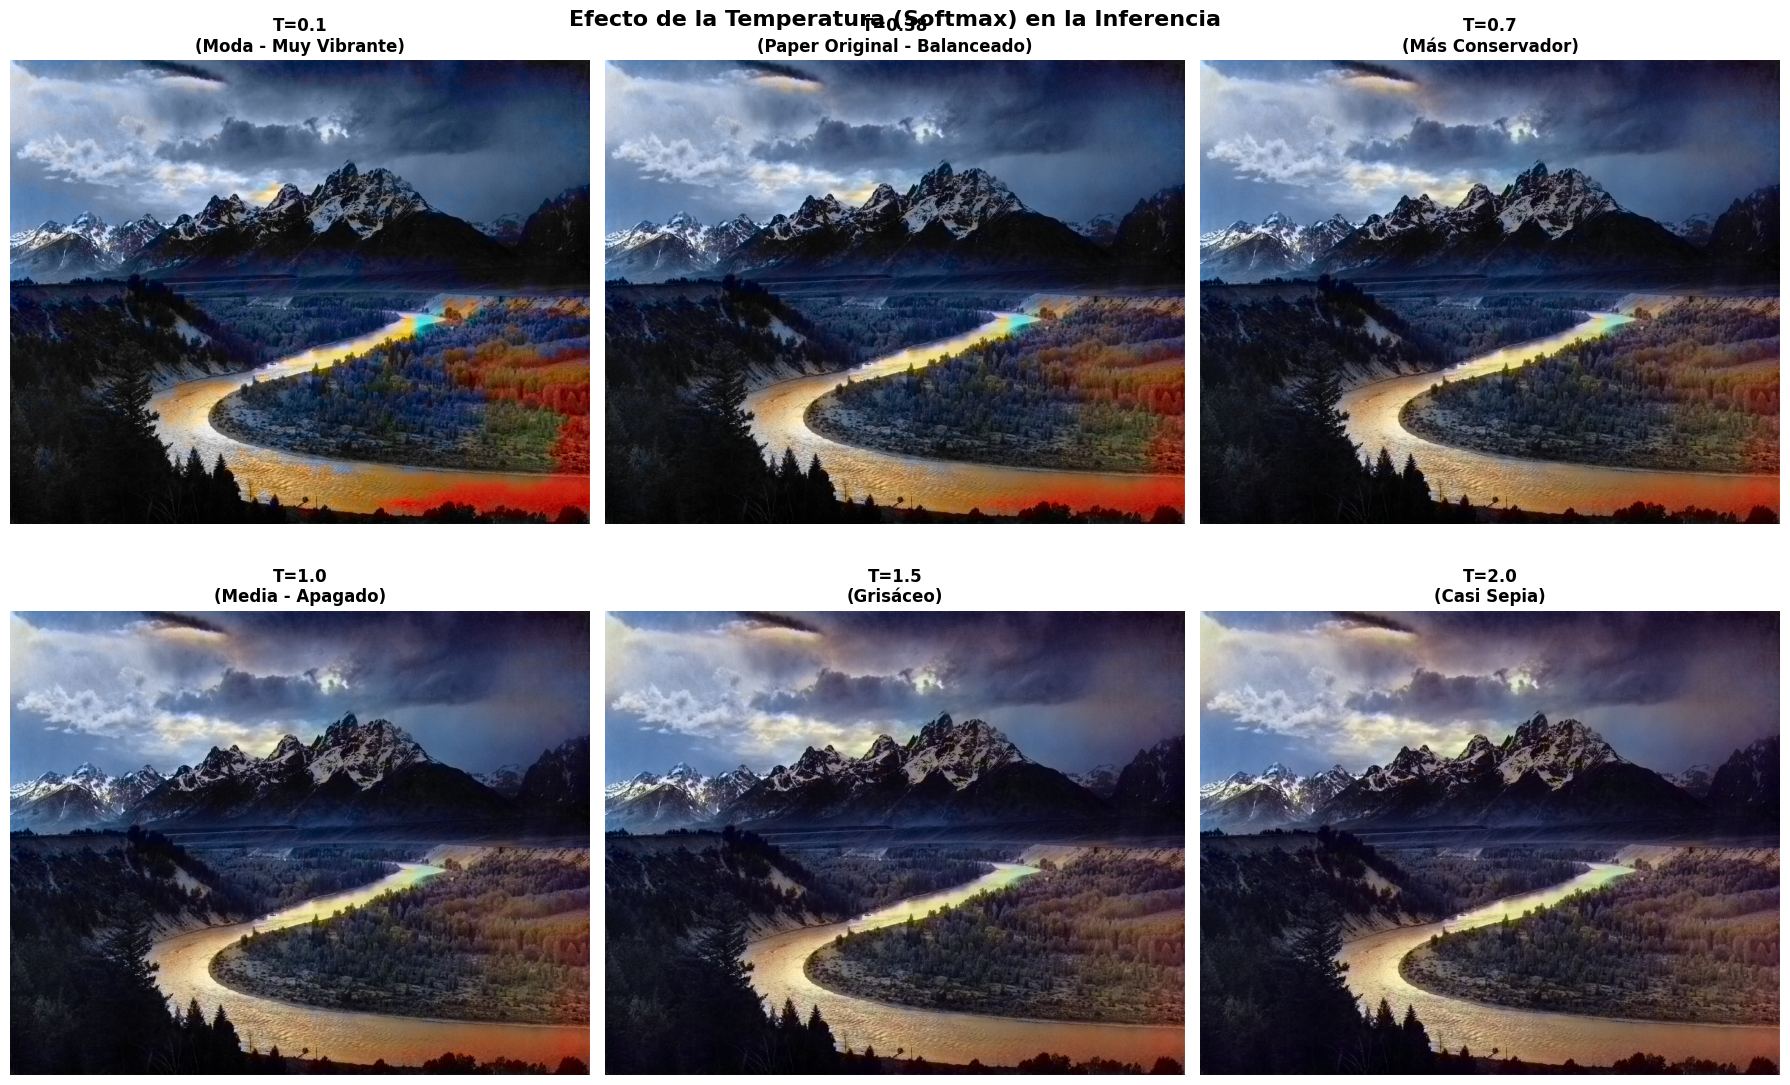


 Análisis visual de la teoría:
• T < 1.0 (ej. 0.38): La distribución se 'afila'. Gana la opción más probable. Colores vibrantes.
• T > 1.0: La distribución se aplana. Todos los colores se promedian. Resultado grisáceo.
• T = 0.38 es el valor recomendado por los autores (Zhang et al.)


In [27]:

# --- CONFIGURACIÓN INICIAL ---
# Cargar imagen
gray_path = "./imgs/ansel_adams.jpg" # Asegúrate de que la ruta sea correcta
img_gray = cv.imread(str(gray_path), cv.IMREAD_GRAYSCALE)
img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)

# --- CARGAR MODELO (UNA SOLA VEZ) ---
# Esto es mucho más eficiente
print("Cargando modelo neuronal...")
PROTOTXT = "./models/colorization_deploy_v2.prototxt"
CAFFEMODEL = "./models/colorization_release_v2.caffemodel"
net = cv.dnn.readNetFromCaffe(PROTOTXT, CAFFEMODEL)

# Configuración específica de capas (kernels especiales del paper)
# Nota: pts_in_hull ya lo cargamos arriba globalmente
net.getLayer(net.getLayerId('class8_ab')).blobs = [pts_in_hull.transpose().reshape(2, 313, 1, 1).astype('float32')]
net.getLayer(net.getLayerId('conv8_313_rh')).blobs = [np.full((1,313), 2.606, 'float32')]

# --- EXPERIMENTO DE TEMPERATURA ---
# Nota el cambio: T baja = Colores fuertes / T alta = Colores grises
temperatures = [0.1, 0.38, 0.7, 1.0, 1.5, 2.0]
temp_labels = [
    'T=0.1\n(Moda - Muy Vibrante)', 
    'T=0.38\n(Paper Original - Balanceado)', 
    'T=0.7\n(Más Conservador)', 
    'T=1.0\n(Media - Apagado)', 
    'T=1.5\n(Grisáceo)', 
    'T=2.0\n(Casi Sepia)'
]

results = []
print("Generando colorizaciones con diferentes temperaturas...")

for i, temp in enumerate(temperatures):
    print(f"  Procesando T={temp}...")
    # AQUI pasamos 'net' como argumento
    colorized = colorize_with_temperature(img_gray_bgr, net, temperature=temp)
    results.append(colorized)

print("Todas las colorizaciones completadas")

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (result, label) in enumerate(zip(results, temp_labels)):
    # Convertir BGR a RGB para matplotlib
    axes[i].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Efecto de la Temperatura (Softmax) en la Inferencia', 
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

# --- ANÁLISIS AUTOMÁTICO (TEXTO CORREGIDO) ---
print(f"\n Análisis visual de la teoría:")
print("• T < 1.0 (ej. 0.38): La distribución se 'afila'. Gana la opción más probable. Colores vibrantes.")
print("• T > 1.0: La distribución se aplana. Todos los colores se promedian. Resultado grisáceo.")
print("• T = 0.38 es el valor recomendado por los autores (Zhang et al.)")

### Aplicación de Temperatura a las Imágenes del Dataset

Ahora vamos a aplicar diferentes temperaturas a nuestras imágenes principales (`Imagen01.jpg`, `Imagen02.jpg`, `Imagen03.jpg`) y guardar los resultados para análisis posterior:


Cargando modelo neuronal en memoria...

 Procesando imágenes del dataset con diferentes temperaturas...
 Guardando en: C:\Users\ander\Desktop\PID\Proyecto\imgs_out\temperature_analysis

 Procesando Imagen01.jpg...
    T=0.2 (conservador)...
    T=1.0 (estandar)...
    T=5.0 (arriesgado)...


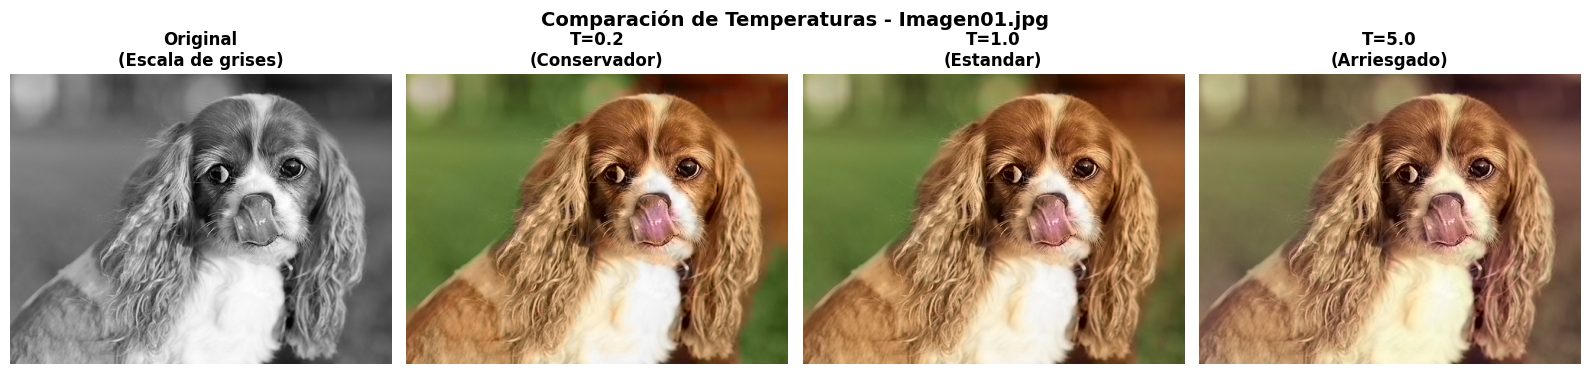

    Guardado: Imagen01_comparison.png

 Procesando Imagen02.jpg...
    T=0.2 (conservador)...
    T=1.0 (estandar)...
    T=5.0 (arriesgado)...


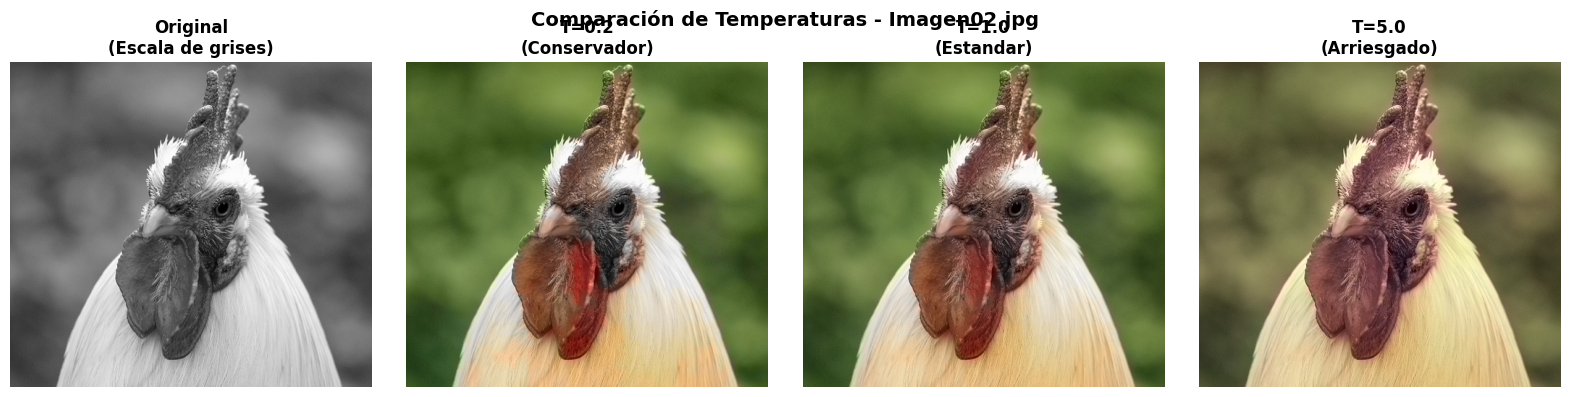

    Guardado: Imagen02_comparison.png

 Procesando Imagen03.jpg...
    T=0.2 (conservador)...
    T=1.0 (estandar)...
    T=5.0 (arriesgado)...


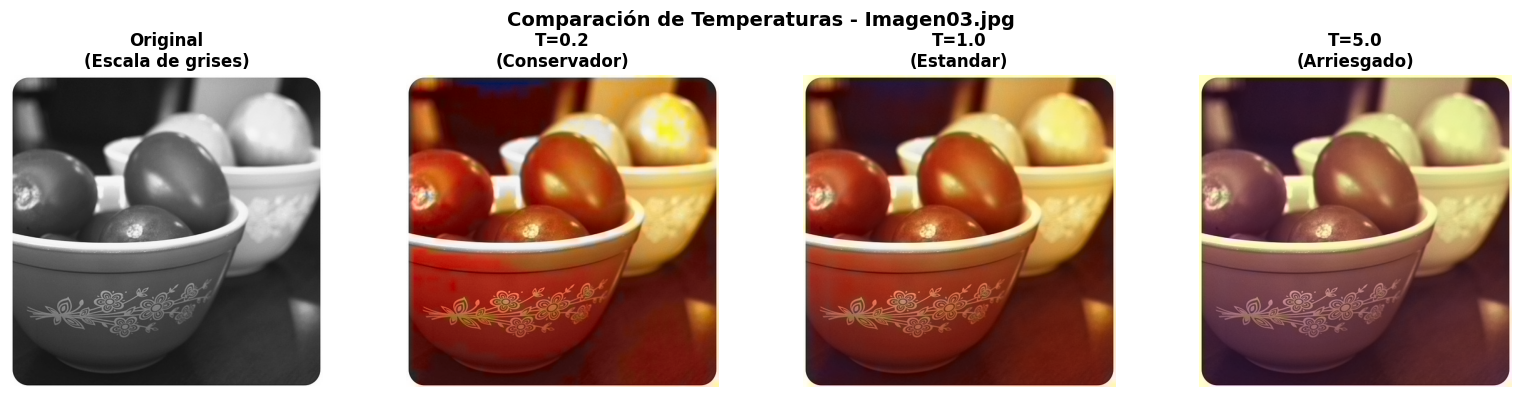

    Guardado: Imagen03_comparison.png


In [32]:
print("Cargando modelo neuronal en memoria...")
PROTOTXT = "./models/colorization_deploy_v2.prototxt"
CAFFEMODEL = "./models/colorization_release_v2.caffemodel"
net = cv.dnn.readNetFromCaffe(PROTOTXT, CAFFEMODEL)

# --- 1.5 CONFIGURACIÓN CRUCIAL (LO QUE FALTABA) ---
# Sin esto, la red está "hueca" en las capas finales y da error
pts_in_hull = np.load("./models/pts_in_hull.npy") # Asegúrate de que este archivo existe
pts_in_hull = pts_in_hull.transpose().reshape(2, 313, 1, 1).astype(np.float32)

# Cargamos los centros de color en la capa class8_ab
net.getLayer(net.getLayerId('class8_ab')).blobs = [pts_in_hull]

# Cargamos el factor de escala en la capa conv8_313_rh (Esta es la que daba el error)
net.getLayer(net.getLayerId('conv8_313_rh')).blobs = [np.full((1,313), 2.606, 'float32')]

# --- 2. CONFIGURACIÓN DEL PROCESAMIENTO ---
selected_temps = [0.2, 1.0, 5.0]
temp_names = ['conservador', 'estandar', 'arriesgado']
temp_dir = DATA_RES / 'temperature_analysis'
temp_dir.mkdir(exist_ok=True)

print("\n Procesando imágenes del dataset con diferentes temperaturas...")
print(f" Guardando en: {temp_dir}")

# Procesar cada imagen original
img_paths = sorted([p for p in DATA_RAW.glob('I*.jpg') if not p.name.endswith('_gray.jpg')])

for img_path in img_paths:
    print(f"\n Procesando {img_path.name}...")
    
    img_color_bgr = cv.imread(str(img_path))
    if img_color_bgr is None: continue # Seguridad por si la imagen falla
    
    if len(img_color_bgr.shape) == 3:
        img_gray = cv.cvtColor(img_color_bgr, cv.COLOR_BGR2GRAY)
    else:
        img_gray = img_color_bgr
        
    img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)
    
    temp_results = []
    for temp, name in zip(selected_temps, temp_names):
        print(f"    T={temp} ({name})...")
        # Ahora sí funcionará porque 'net' ya tiene los blobs cargados
        colorized = colorize_with_temperature(img_gray_bgr, net, temperature=temp)
        temp_results.append(colorized)
        
        output_path = temp_dir / f'{img_path.stem}_temp_{temp}.jpg'
        cv.imwrite(str(output_path), colorized)
    
    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Original\n(Escala de grises)', fontweight='bold')
    axes[0].axis('off')
    
    for i, (result, temp, name) in enumerate(zip(temp_results, selected_temps, temp_names)):
        axes[i+1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
        axes[i+1].set_title(f'T={temp}\n({name.capitalize()})', fontweight='bold')
        axes[i+1].axis('off')
    
    plt.suptitle(f'Comparación de Temperaturas - {img_path.name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    comparison_path = temp_dir / f'{img_path.stem}_comparison.png'
    plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
    plt.show() # Importante: plt.show() limpia la figura para la siguiente iteración
    print(f"    Guardado: {comparison_path.name}")